# Digital-Gold ₿
### Is bitcoin really 'digital gold' — a store of value that protects you?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Bitcoin is digital gold?: Not supported](https://img.shields.io/badge/Bitcoin_is_digital_gold%3F-Not_supported-8b949e?style=flat-square)

Bitcoin's biggest selling point is that it's the new gold: scarce, a hedge against inflation and chaos, a safe haven. We checked. Bitcoin doesn't move like gold at all — it moves *increasingly like the stock market*, and in a crash it falls **harder** than stocks and never rises. It's been a phenomenal bet, but it's the opposite of a haven.

> 📓 **Plain-language layer.** The correlations, their drift and the crash behaviour are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every number is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (digital_gold/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from digital_gold import data, strategy as st
ret = data.fetch_panel()                       # cache-first (BTC/SPY/GLD pull)
corr = st.correlations(ret)
monthly = (1 + ret).resample("ME").prod() - 1
cb = st.crisis_behavior(monthly)


## The answer first 🎯

| The question | The data (BTC/SPY/GLD, 2014–2026) |
|---|---|
| "Does BTC move like gold?" | No: correlation with gold just **+0.09**. |
| "Is it a safe haven?" | No: in crashes **−18% vs stocks −10%**, up **0%** of the time. |
| "So what is it?" | A **high-beta risk asset** (+64%/yr, but −83% drawdown). |

## 1 · The claim

Bitcoin is 'digital gold' — a scarce, decentralized store of value that hedges inflation and crisis, a modern substitute for the metal. The folk version: *when the system wobbles, bitcoin (like gold) protects you.*

## 2 · So what?

If true, BTC would deserve a place beside gold as portfolio insurance. If instead it's just a very volatile risk asset, then owning it is a *return* bet — and sizing it as 'insurance' would be exactly backwards when a crisis hits.

## 3 · How would we even know?

Compare BTC's correlation with gold and with stocks (and how that's changed over time), then watch what BTC does in the worst months for equities — the moment a haven is supposed to earn its keep.

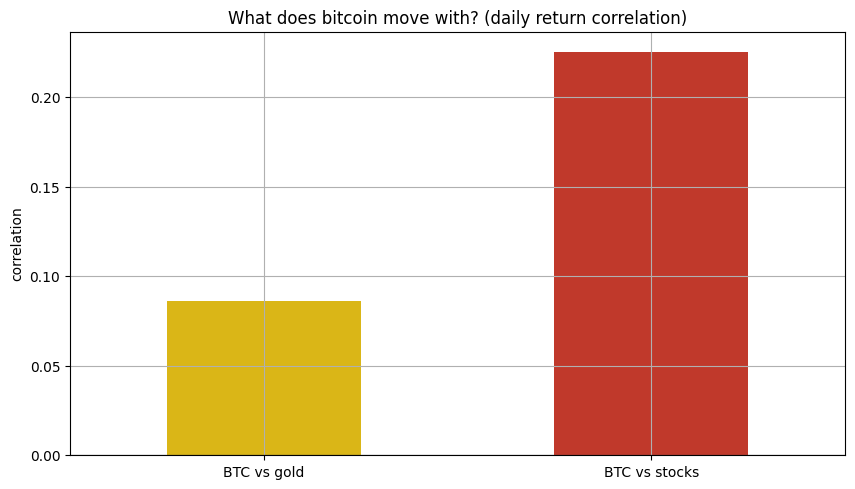

BTC-stock correlation: +0.13 (early) -> +0.36 (recent)


In [2]:
bars=pd.Series({'BTC vs gold':corr['btc_gold'],'BTC vs stocks':corr['btc_stock']})
ax=bars.plot.bar(rot=0,color=['#dab617','#c0392b'],title='What does bitcoin move with? (daily return correlation)')
ax.set_ylabel('correlation'); ax.axhline(0,color='k',lw=.8); plt.show()
print(f"BTC-stock correlation: {corr['btc_stock_first']:+.2f} (early) -> {corr['btc_stock_second']:+.2f} (recent)")

## 4 · The teardown — it crashes *with* stocks, not against them

In the worst equity months, a haven holds or rises. Bitcoin did the opposite — it fell nearly twice as hard.

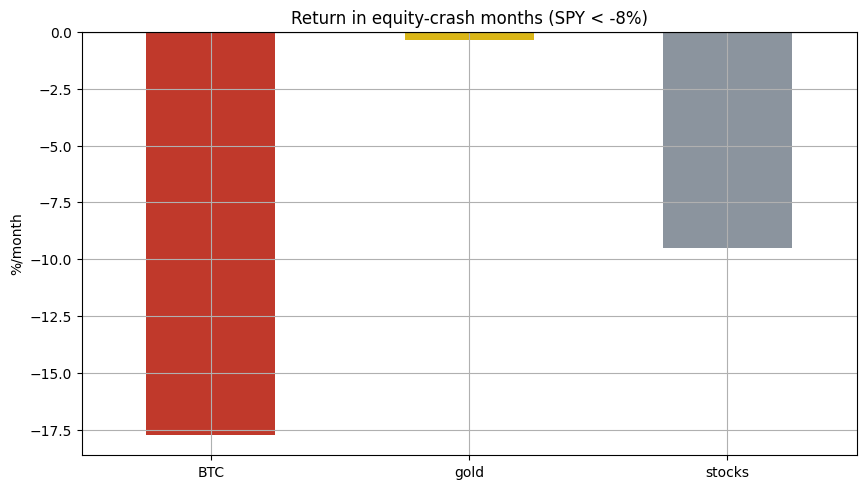

BTC rose in 0% of 5 crash months; gold in 20%


In [3]:
bars=pd.Series({'BTC':cb['btc_in_crash'],'gold':cb['gold_in_crash'],'stocks':cb['eq_in_crash']})*100
ax=bars.plot.bar(rot=0,color=['#c0392b','#dab617','#8b949e'],title='Return in equity-crash months (SPY < -8%)')
ax.set_ylabel('%/month'); ax.axhline(0,color='k',lw=.8); plt.show()
print(f"BTC rose in {cb['btc_up_share']:.0%} of {cb['n_crash']} crash months; gold in {cb['gold_up_share']:.0%}")

**Read it plainly.** Bitcoin is near-uncorrelated with *gold* and increasingly correlated with *stocks* — and when stocks crashed it fell harder and never rallied. It's a leveraged risk-on asset. It's also returned ~64%/yr, so a small sleeve flattered a portfolio — but that's a bet on the trend continuing, carrying an 83% drawdown, not a hedge.

## 5 · The verdict

**Signal: None** (as digital gold) — uncorrelated with gold, falls in crashes. **Tradability: Fragile** — a small sleeve helped, but on a huge, drawdown-heavy trend. **Bitcoin is digital gold?: Not supported.**

## 6 · Could you actually trade it?

Only as a high-risk *growth* sleeve, sized for an 80%+ drawdown — never as the haven it's marketed to be. If you want crisis ballast, that's gold's (imperfect) job ([69 Safe-Haven](../../69-safe-haven/)); bitcoin is the thing you'd want *less* of going into a storm.

## 7 · Going further 🚪

The counterpart to [69 Safe-Haven](../../69-safe-haven/) (the gold it's pitched to replace) and a diversification cousin of [68 All-Weather](../../68-all-weather/). Forks: vol-targeted BTC sizing, the post-ETF (2024) correlation regime, BTC vs gold across specific crises (COVID, 2022).